🔄 Đang chạy clean_dataset.py...


🚀 Bắt đầu quy trình chuẩn hóa và làm sạch dataset song ngữ thời trang...
📦 Đã tải dataset thành công: 40,305 dòng dữ liệu.

[Bước 1] Loại bỏ các dòng chứa giá trị rỗng (NaN)...
👉 Loại bỏ 0 dòng chứa giá trị rỗng. Còn lại 40,305 dòng.

[Bước 2] Thực hiện chuẩn hóa Unicode NFC và dọn dẹp văn bản (HTML, URL, khoảng trắng)...
👉 Dọn dẹp khoảng trắng & loại chuỗi rỗng hoàn tất. Còn lại 40,305 dòng.

[Bước 3] Loại bỏ các bản dịch trùng lặp câu gốc (dịch lỗi chưa dịch)...
👉 Loại bỏ 0 dòng chưa dịch. Còn lại 40,305 dòng.

[Bước 4] Áp dụng logic khử trùng lặp và tính điểm chất lượng bản dịch (Smart Deduplication)...
👉 Khử trùng lặp thông minh hoàn tất (Đã loại bỏ 567 dòng trùng lặp). Còn lại 39,738 dòng.

[Bước 5] Kiểm tra phân loại nhận diện ngôn ngữ sử dụng langdetect...
👉 Loại bỏ 0 dòng lỗi ngôn ngữ/dịch sai tiếng. Còn lại 39,738 dòng.

[Bước 6] Áp dụng lọc độ dài tối đa/tối thiểu và tỷ lệ số từ (Length & Ratio Filtering)...
👉 Loại bỏ 180 dòng lệch tỷ lệ hoặc quá dài/quá ngắn. Còn lại 39,558 

🚀 Bắt đầu quy trình chắt lọc bộ dữ liệu 10k dòng tinh túy...
📦 Đã tải dữ liệu sạch: 37,441 dòng.
⏳ Đang phân tích độ phức tạp và chấm điểm chất lượng từng dòng...
⏳ Đang lựa chọn 10,000 dòng dữ liệu tinh túy nhất...
💾 Đã lưu CSV sạch tại: D:\Learning\ky_5\DPL302m\Project\fashion_match\traslate\processed\cleaned_balanced_10k_dataset.csv
⏳ Đang chuyển đổi định dạng sang JSON Lines (ChatML)...
💾 Đã lưu JSONL sạch tại: D:\Learning\ky_5\DPL302m\Project\fashion_match\traslate\processed\training_ready_10k_dataset.jsonl

📊 THỐNG KÊ CHI TIẾT BỘ DỮ LIỆU TINH TÚY 10K
🔹 Tổng số dòng được trích xuất:  10,000 dòng
🔹 Độ dài trung bình Prompt (User): 28.1 từ
🔹 Độ dài trung bình Completion (Model): 126.0 từ
🎉 QUY TRÌNH CHẮT LỌC HOÀN THÀNH XUẤT SẮC!
Bây giờ bạn chỉ cần copy file 'training_ready_10k_dataset.jsonl' lên Kaggle và chạy train!



Số lượng dòng ban đầu: 40,305 dòng
Số lượng dòng sau khi chuẩn hóa hoàn chỉnh (10k dòng): 10,000 dòng


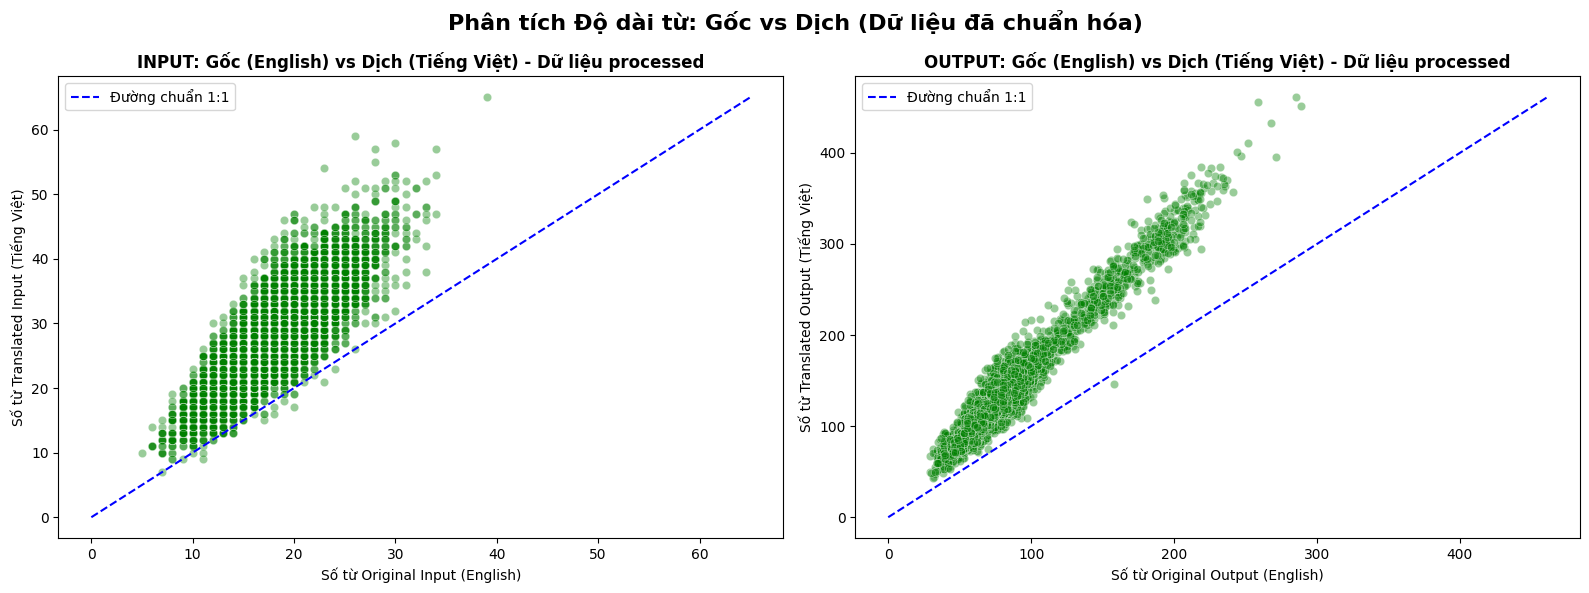

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Tải dữ liệu từ thư mục raw
file_path = '../raw/finetuning_data_fashion_knowledge.csv'
df = pd.read_csv(file_path)

# Loại bỏ các dòng bị rỗng ban đầu để có dữ liệu cơ sở
df_raw = df.dropna(subset=['original_input', 'original_output', 'translated_input', 'translated_output']).copy()

# Tính độ dài từ (Word Count) để chuẩn bị cho quá trình chuẩn hóa
epsilon = 1e-5
df_raw['en_in_wc'] = df_raw['original_input'].astype(str).apply(lambda x: len(x.split()))
df_raw['en_out_wc'] = df_raw['original_output'].astype(str).apply(lambda x: len(x.split()))
df_raw['vi_in_wc'] = df_raw['translated_input'].astype(str).apply(lambda x: len(x.split()))
df_raw['vi_out_wc'] = df_raw['translated_output'].astype(str).apply(lambda x: len(x.split()))
df_raw['in_ratio'] = df_raw['vi_in_wc'] / (df_raw['en_in_wc'] + epsilon)
df_raw['out_ratio'] = df_raw['vi_out_wc'] / (df_raw['en_out_wc'] + epsilon)

# 2. Quy trình chuẩn hóa bộ dữ liệu (Data Normalization Pipeline)
# Gọi script clean_dataset.py để thực hiện các bộ lọc chuẩn hóa nâng cao
# Gọi script prune_dataset.py để thực hiện chắt lọc 10k dòng tinh túy
import subprocess
import sys
import os

print("🔄 Đang chạy clean_dataset.py...")
script_clean = os.path.abspath(os.path.join(os.getcwd(), '..', 'clean_dataset.py'))
if not os.path.exists(script_clean):
    script_clean = os.path.abspath('clean_dataset.py')
result_clean = subprocess.run([sys.executable, script_clean], capture_output=True, text=True, encoding='utf-8')
print(result_clean.stdout)
if result_clean.returncode != 0:
    print("❌ Lỗi chạy clean_dataset.py:", result_clean.stderr)

print("🔄 Đang chạy prune_dataset.py...")
script_prune = os.path.abspath(os.path.join(os.getcwd(), '..', 'prune_dataset.py'))
if not os.path.exists(script_prune):
    script_prune = os.path.abspath('prune_dataset.py')
result_prune = subprocess.run([sys.executable, script_prune], capture_output=True, text=True, encoding='utf-8')
print(result_prune.stdout)
if result_prune.returncode != 0:
    print("❌ Lỗi chạy prune_dataset.py:", result_prune.stderr)

df_clean = pd.read_csv('cleaned_balanced_10k_dataset.csv')
df_clean['en_in_wc'] = df_clean['original_input'].astype(str).apply(lambda x: len(x.split()))
df_clean['en_out_wc'] = df_clean['original_output'].astype(str).apply(lambda x: len(x.split()))
df_clean['vi_in_wc'] = df_clean['translated_input'].astype(str).apply(lambda x: len(x.split()))
df_clean['vi_out_wc'] = df_clean['translated_output'].astype(str).apply(lambda x: len(x.split()))
epsilon = 1e-5
df_clean['in_ratio'] = df_clean['vi_in_wc'] / (df_clean['en_in_wc'] + epsilon)
df_clean['out_ratio'] = df_clean['vi_out_wc'] / (df_clean['en_out_wc'] + epsilon)

print(f"Số lượng dòng ban đầu: {len(df):,} dòng")
print(f"Số lượng dòng sau khi chuẩn hóa hoàn chỉnh (10k dòng): {len(df_clean):,} dòng")

# 3. Vẽ biểu đồ Phân tích Độ dài từ (Grid 1x2 cho tập dữ liệu sạch processed)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 0: INPUT (EN vs VI)
sns.scatterplot(data=df_clean, x='en_in_wc', y='vi_in_wc', ax=axes[0], alpha=0.4, color='green')
max_in_clean = max(df_clean['en_in_wc'].max(), df_clean['vi_in_wc'].max())
axes[0].plot([0, max_in_clean], [0, max_in_clean], 'b--', label='Đường chuẩn 1:1')
axes[0].set_title('INPUT: Gốc (English) vs Dịch (Tiếng Việt) - Dữ liệu processed', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số từ Original Input (English)')
axes[0].set_ylabel('Số từ Translated Input (Tiếng Việt)')
axes[0].legend()

# Subplot 1: OUTPUT (EN vs VI)
sns.scatterplot(data=df_clean, x='en_out_wc', y='vi_out_wc', ax=axes[1], alpha=0.4, color='green')
max_out_clean = max(df_clean['en_out_wc'].max(), df_clean['vi_out_wc'].max())
axes[1].plot([0, max_out_clean], [0, max_out_clean], 'b--', label='Đường chuẩn 1:1')
axes[1].set_title('OUTPUT: Gốc (English) vs Dịch (Tiếng Việt) - Dữ liệu processed', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số từ Original Output (English)')
axes[1].set_ylabel('Số từ Translated Output (Tiếng Việt)')
axes[1].legend()

plt.suptitle("Phân tích Độ dài từ: Gốc vs Dịch (Dữ liệu đã chuẩn hóa)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('word_count_scatter_processed.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_2456\2863818314.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist, x='Số phiên bản dịch', y='Số lượng câu', ax=ax, palette=['#2ecc71'])
C:\Users\hi\AppData\Local\Temp\ipykernel_2456\2863818314.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist, x='Số phiên bản dịch', y='Số lượng câu', ax=ax, palette=['#2ecc71'])


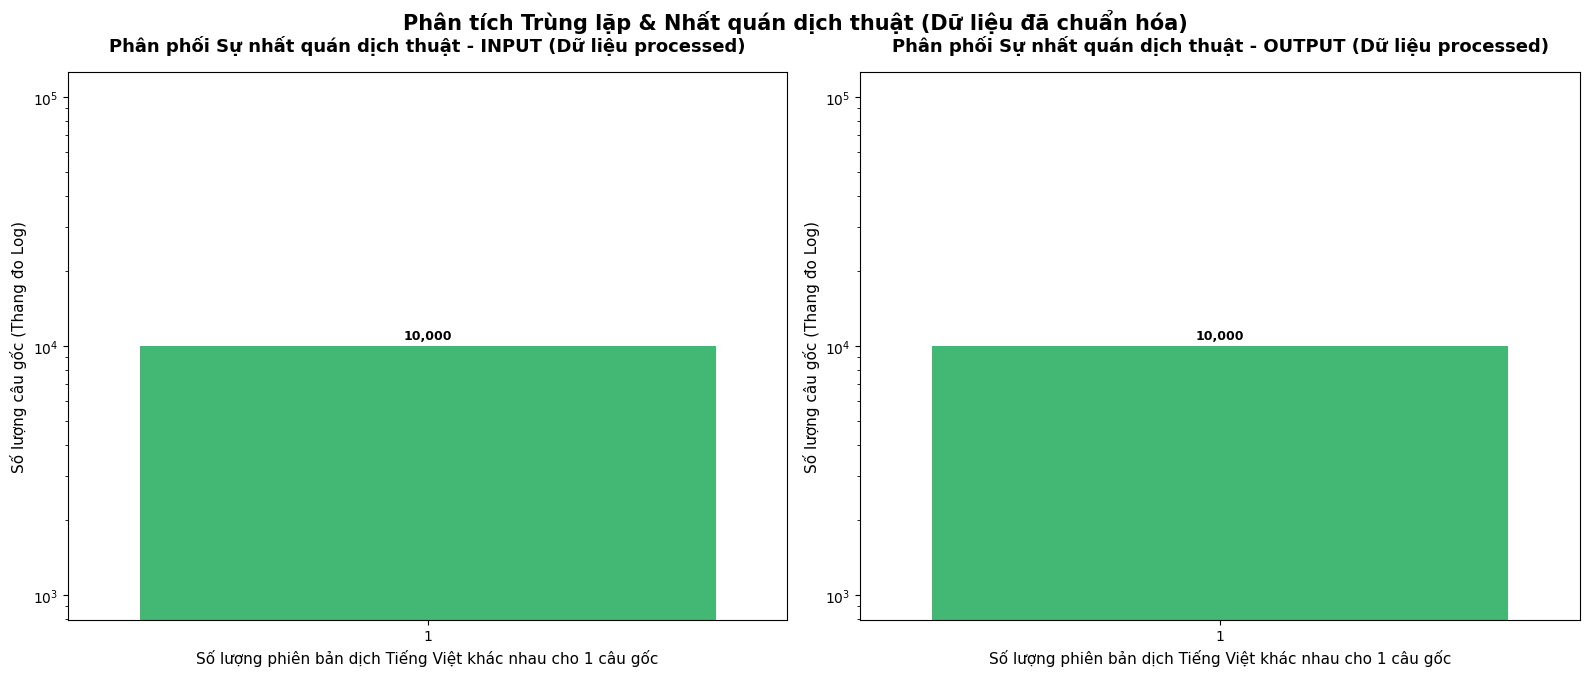

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_consistency_dist(dataframe):
    df_temp = dataframe.dropna(subset=['original_input', 'original_output', 'translated_input', 'translated_output']).copy()
    df_temp['trans_in_clean'] = df_temp['translated_input'].astype(str).str.strip().str.lower()
    df_temp['trans_out_clean'] = df_temp['translated_output'].astype(str).str.strip().str.lower()
    
    in_dist = df_temp.groupby('original_input')['trans_in_clean'].nunique().value_counts().sort_index().reset_index()
    in_dist.columns = ['Số phiên bản dịch', 'Số lượng câu']
    
    out_dist = df_temp.groupby('original_output')['trans_out_clean'].nunique().value_counts().sort_index().reset_index()
    out_dist.columns = ['Số phiên bản dịch', 'Số lượng câu']
    
    return in_dist, out_dist

in_clean_dist, out_clean_dist = get_consistency_dist(df_clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def plot_consistency_single(ax, dist, title_suffix):
    sns.barplot(data=dist, x='Số phiên bản dịch', y='Số lượng câu', ax=ax, palette=['#2ecc71'])
    ax.set_yscale('log')
    ax.set_title(f'Phân phối Sự nhất quán dịch thuật - {title_suffix} (Dữ liệu processed)', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Số lượng phiên bản dịch Tiếng Việt khác nhau cho 1 câu gốc', fontsize=11)
    ax.set_ylabel('Số lượng câu gốc (Thang đo Log)', fontsize=11)
    
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.annotate(f'{int(height):,}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                        textcoords='offset points', weight='bold')

plot_consistency_single(axes[0], in_clean_dist, "INPUT")
plot_consistency_single(axes[1], out_clean_dist, "OUTPUT")

plt.suptitle("Phân tích Trùng lặp & Nhất quán dịch thuật (Dữ liệu đã chuẩn hóa)", fontsize=15, fontweight='bold', y=0.96)
plt.tight_layout()
plt.savefig('volume_processed.png', dpi=300, bbox_inches='tight')
plt.show()


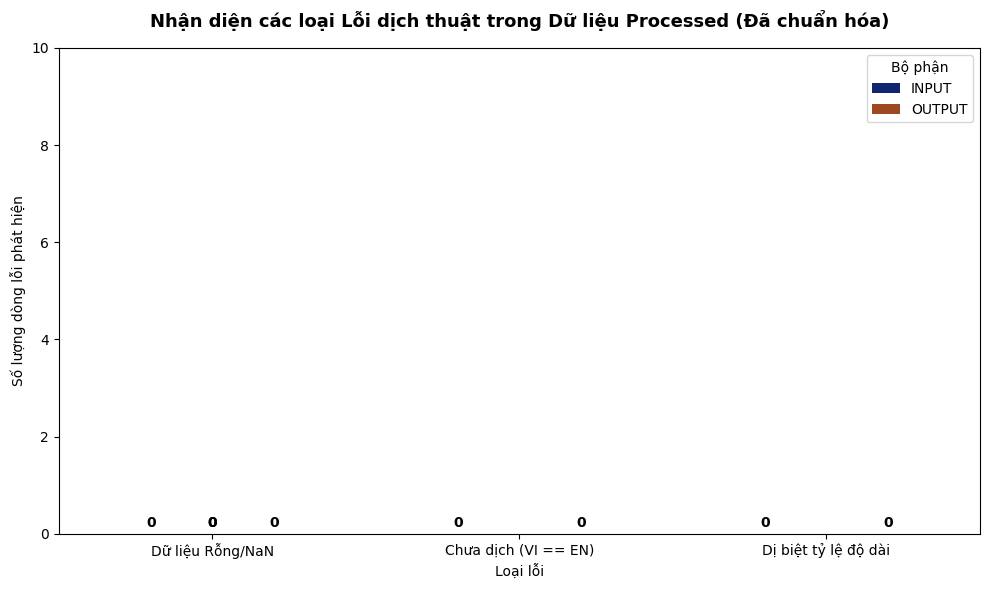

In [3]:
# 3. Nhận diện các lỗi dịch thuật chính trong dữ liệu processed (Bộ 10k đã làm sạch)
import re
from langdetect import detect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Rỗng/NaN
empty_trans_in = df_clean['translated_input'].isna().sum() + (df_clean['translated_input'].astype(str).str.strip() == '').sum()
empty_trans_out = df_clean['translated_output'].isna().sum() + (df_clean['translated_output'].astype(str).str.strip() == '').sum()

# 2. Chưa dịch (VI == EN)
untrans_in = (df_clean['original_input'].astype(str).str.strip() == df_clean['translated_input'].astype(str).str.strip()).sum()
untrans_out = (df_clean['original_output'].astype(str).str.strip() == df_clean['translated_output'].astype(str).str.strip()).sum()

# 3. Trùng lặp cặp QA English
dup_count = df_clean.duplicated(subset=['original_input', 'original_output']).sum()

# 4. Dị biệt tỷ lệ độ dài
anom_in = ((df_clean['in_ratio'] < 0.4) | (df_clean['in_ratio'] > 2.5)).sum()
anom_out = ((df_clean['out_ratio'] < 0.4) | (df_clean['out_ratio'] > 2.5)).sum()

# 5. Dịch lệch số
re_numbers = re.compile(r'\b\d+\b')
def is_num_mismatch(row):
    en = (str(row['original_input']) + ' ' + str(row['original_output'])).lower()
    vi = (str(row['translated_input']) + ' ' + str(row['translated_output'])).lower()
    en_nums = {n for n in re_numbers.findall(en) if len(n) >= 2}
    vi_nums = {n for n in re_numbers.findall(vi) if len(n) >= 2}
    return not en_nums.issubset(vi_nums)

num_mismatches = df_clean.apply(is_num_mismatch, axis=1).sum()

# 6. Mất thực thể thời trang
def is_entity_loss(row):
    en = (str(row['original_input']) + ' ' + str(row['original_output'])).lower()
    vi = (str(row['translated_input']) + ' ' + str(row['translated_output'])).lower()
    entity_detections = 0
    entity_matches = 0
    for cat, terms in entities.items():
        for en_term, vi_terms in terms.items():
            if re.search(r'\b' + re.escape(en_term) + r'\b', en):
                entity_detections += 1
                if any(vi_term in vi for vi_term in vi_terms):
                    entity_matches += 1
    return entity_detections > 0 and entity_matches == 0

entity_losses = df_clean.apply(is_entity_loss, axis=1).sum()

# 7. Lỗi nhận diện ngôn ngữ
re_vi_chars = re.compile(r'[àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]', re.IGNORECASE)
def is_lang_error(row):
    en_text = str(row['original_input']) + ' ' + str(row['original_output'])
    vi_text = str(row['translated_input']) + ' ' + str(row['translated_output'])
    if len(en_text.strip()) > 15:
        try:
            detected = detect(en_text)
            if detected != 'en' and detected not in ['en', 'ca', 'ro', 'it', 'fr']:
                return True
        except:
            pass
    if len(vi_text.strip()) > 15:
        try:
            detected = detect(vi_text)
            has_vi_chars = bool(re_vi_chars.search(vi_text))
            if detected != 'vi' and not has_vi_chars:
                return True
        except:
            pass
    return False

lang_errors = df_clean.apply(is_lang_error, axis=1).sum()

# 8. Câu quá dài
too_long_in = (df_clean['vi_in_wc'] > 350).sum()
too_long_out = (df_clean['vi_out_wc'] > 700).sum()

errors_data = pd.DataFrame([
    {'Loại lỗi': 'NaN / Rỗng', 'Bộ phận': 'INPUT', 'Số lượng': empty_trans_in},
    {'Loại lỗi': 'NaN / Rỗng', 'Bộ phận': 'OUTPUT', 'Số lượng': empty_trans_out},
    {'Loại lỗi': 'Chưa dịch', 'Bộ phận': 'INPUT', 'Số lượng': untrans_in},
    {'Loại lỗi': 'Chưa dịch', 'Bộ phận': 'OUTPUT', 'Số lượng': untrans_out},
    {'Loại lỗi': 'Trùng lặp', 'Bộ phận': 'QA Pair', 'Số lượng': dup_count},
    {'Loại lỗi': 'Lệch tỷ lệ độ dài', 'Bộ phận': 'INPUT', 'Số lượng': anom_in},
    {'Loại lỗi': 'Lệch tỷ lệ độ dài', 'Bộ phận': 'OUTPUT', 'Số lượng': anom_out},
    {'Loại lỗi': 'Dịch lệch số', 'Bộ phận': 'QA Pair', 'Số lượng': num_mismatches},
    {'Loại lỗi': 'Mất thực thể', 'Bộ phận': 'QA Pair', 'Số lượng': entity_losses},
    {'Loại lỗi': 'Sai ngôn ngữ', 'Bộ phận': 'QA Pair', 'Số lượng': lang_errors},
    {'Loại lỗi': 'Câu quá dài', 'Bộ phận': 'INPUT', 'Số lượng': too_long_in},
    {'Loại lỗi': 'Câu quá dài', 'Bộ phận': 'OUTPUT', 'Số lượng': too_long_out}
])

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=errors_data, x='Loại lỗi', y='Số lượng', hue='Bộ phận', ax=ax, palette='dark')
ax.set_title('Nhận diện các loại Lỗi dịch thuật trong Dữ liệu Processed (Bộ 10k sạch)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Số lượng dòng lỗi phát hiện')
ax.set_ylim(0, 10)
ax.tick_params(axis='x', rotation=30)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3),
                textcoords='offset points', weight='bold')

plt.tight_layout()
plt.savefig('length_ratio_processed.png', dpi=300, bbox_inches='tight')
plt.show()


🔄 Đang tính toán tỷ lệ bảo toàn thực thể trên dữ liệu processed...


C:\Users\hi\AppData\Local\Temp\ipykernel_2456\664511811.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats_clean_in, x="Category", y="Preservation Rate (%)", ax=axes[0], palette="muted")
C:\Users\hi\AppData\Local\Temp\ipykernel_2456\664511811.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats_clean_out, x="Category", y="Preservation Rate (%)", ax=axes[1], palette="muted")


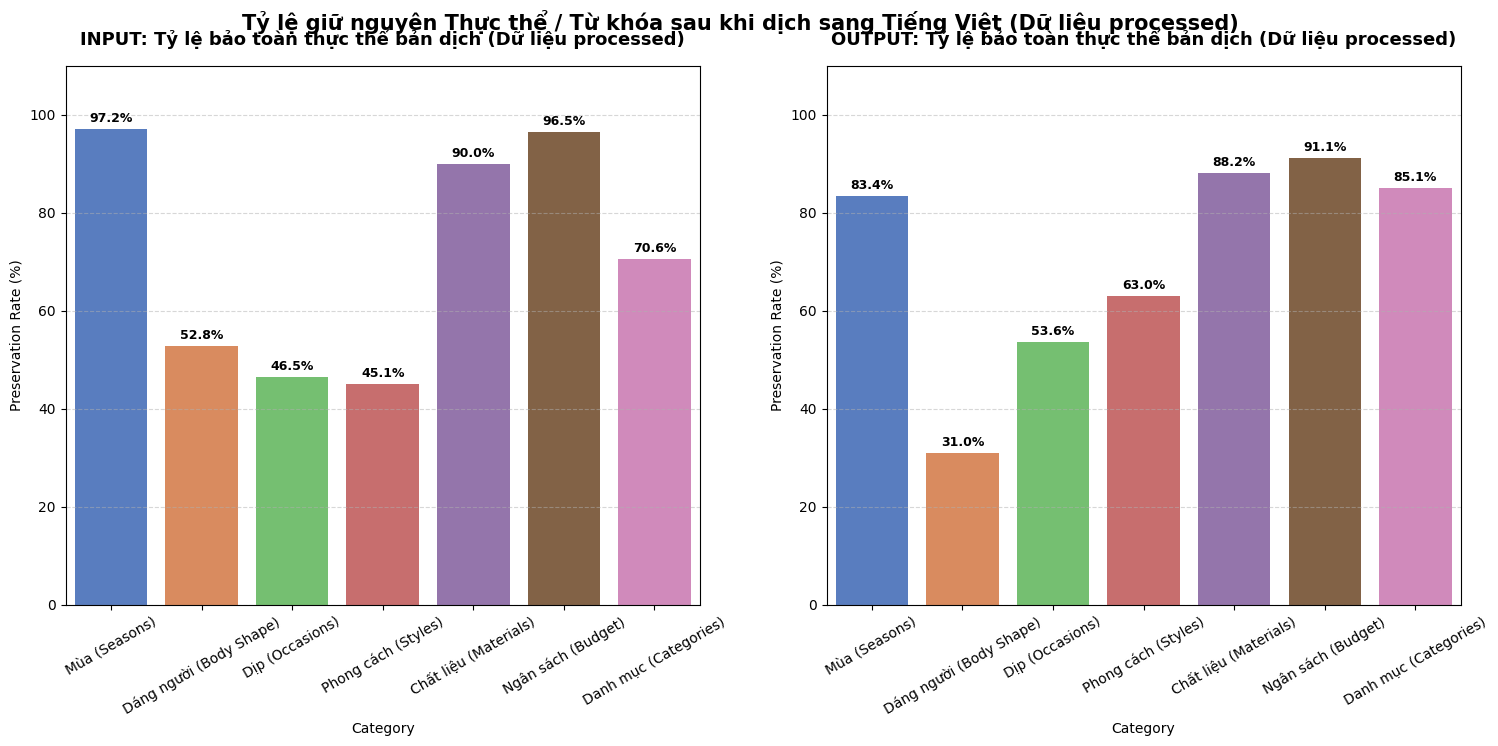

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Định nghĩa danh sách các thực thể / từ khóa
entities = {
    "Mùa (Seasons)": {
        "summer": ["mùa hè", "hè", "summer"],
        "winter": ["mùa đông", "đông", "winter"],
        "spring": ["mùa xuân", "xuân", "spring"],
        "autumn": ["mùa thu", "thu", "autumn"],
        "fall": ["mùa thu", "thu", "fall"]
    },
    "Dáng người (Body Shape)": {
        "inverted triangle": ["tam giác ngược", "inverted triangle"],
        "hourglass": ["đồng hồ cát", "hourglass"],
        "pear": ["quả lê", "dáng lê", "pear"],
        "rectangle": ["hình chữ nhật", "dáng suông", "rectangle"],
        "apple": ["quả táo", "apple"],
        "tall": ["cao", "tall"],
        "short": ["thấp", "nấm lùn", "short"],
        "skinny": ["gầy", "ốm", "skinny"],
        "stocky": ["đậm người", "mập mạp", "đô con", "stocky"],
        "muscular": ["cơ bắp", "muscular"]
    },
    "Dịp (Occasions)": {
        "retreat": ["dã ngoại", "nghỉ dưỡng", "retreat"],
        "wedding": ["tiệc cưới", "đám cưới", "wedding"],
        "vacation": ["kỳ nghỉ", "vacation", "du lịch"],
        "work": ["văn phòng", "công sở", "đi làm", "work"],
        "office": ["văn phòng", "công sở", "office"],
        "casual": ["thường ngày", "hàng ngày", "casual"],
        "party": ["tiệc", "party"],
        "formal": ["trang trọng", "lịch sự", "formal"]
    },
    "Phong cách (Styles)": {
        "heritage": ["di sản", "heritage", "rugged heritage"],
        "bohemian": ["bohemian", "boho"],
        "classic": ["cổ điển", "classic"],
        "timeless": ["kinh điển", "trường tồn", "vĩnh cửu", "timeless", "thời thượng"],
        "modern": ["hiện đại", "modern"],
        "sporty": ["thể thao", "sporty"],
        "vintage": ["vintage", "cổ xưa"]
    },
    "Chất liệu (Materials)": {
        "linen": ["linen", "lanh"],
        "cotton": ["cotton", "bông"],
        "denim": ["denim", "bò"],
        "wool": ["len", "wool"],
        "felt": ["nỉ", "dạ", "felt"],
        "straw": ["cói", "rơm", "straw"],
        "silk": ["lụa", "tơ tằm", "silk"],
        "chiffon": ["voan", "chiffon"],
        "leather": ["da", "leather"],
        "canvas": ["bạt", "canvas"],
        "suede": ["da lộn", "suede"],
        "velvet": ["nhung", "velvet"],
        "tweed": ["tweed", "dạ tweed"]
    },
    "Ngân sách (Budget)": {
        "budget": ["ngân sách", "tiết kiệm", "giá rẻ", "budget"],
        "affordable": ["phải chăng", "hợp lý", "affordable"],
        "luxury": ["sang trọng", "xa xỉ", "luxury"]
    },
    "Danh mục (Categories)": {
        "shirt": ["áo", "sơ mi", "áo thun", "shirt"],
        "pants": ["quần", "pants"],
        "suit": ["suit", "vest", "bộ âu phục"],
        "skirt": ["váy", "chân váy", "skirt"],
        "dress": ["đầm", "váy", "dress"],
        "shoe": ["giày", "shoe", "shoes"],
        "boot": ["boot", "bốt", "boots"],
        "hat": ["mũ", "nón", "hat"],
        "accessory": ["phụ kiện", "trang sức", "accessory", "accessories"],
        "blouse": ["blouse", "áo blouse"],
        "jeans": ["jeans", "quần jeans"],
        "blazer": ["blazer", "áo khoác"],
        "jacket": ["áo khoác", "jacket"]
    }
}

en_patterns = {cat: {en_term: re.compile(r'\b' + re.escape(en_term) + r'\b') for en_term in terms.keys()} for cat, terms in entities.items()}
cat_patterns = {cat: re.compile(r'\b(' + '|'.join(map(re.escape, terms.keys())) + r')\b') for cat, terms in entities.items()}

def get_preservation_stats_separated(dataframe):
    stats_in = {cat: {"detected": 0, "preserved": 0} for cat in entities.keys()}
    stats_out = {cat: {"detected": 0, "preserved": 0} for cat in entities.keys()}
    
    orig_in = dataframe['original_input'].astype(str).str.lower().values
    orig_out = dataframe['original_output'].astype(str).str.lower().values
    trans_in = dataframe['translated_input'].astype(str).str.lower().values
    trans_out = dataframe['translated_output'].astype(str).str.lower().values
    
    for idx in range(len(dataframe)):
        text_en_in = orig_in[idx]
        text_en_out = orig_out[idx]
        text_vi_in = trans_in[idx]
        text_vi_out = trans_out[idx]
        
        for cat, terms in entities.items():
            # Check Input
            if cat_patterns[cat].search(text_en_in):
                for en_term, vi_terms in terms.items():
                    pattern = en_patterns[cat][en_term]
                    if pattern.search(text_en_in):
                        stats_in[cat]["detected"] += 1
                        for vi_term in vi_terms:
                            if vi_term in text_vi_in:
                                stats_in[cat]["preserved"] += 1
                                break
                                
            # Check Output
            if cat_patterns[cat].search(text_en_out):
                for en_term, vi_terms in terms.items():
                    pattern = en_patterns[cat][en_term]
                    if pattern.search(text_en_out):
                        stats_out[cat]["detected"] += 1
                        for vi_term in vi_terms:
                            if vi_term in text_vi_out:
                                stats_out[cat]["preserved"] += 1
                                break
                                
    res_in = []
    res_out = []
    for cat in entities.keys():
        det_in = stats_in[cat]["detected"]
        pres_in = stats_in[cat]["preserved"]
        rate_in = (pres_in / det_in * 100) if det_in > 0 else 0
        res_in.append({"Category": cat, "Preservation Rate (%)": round(rate_in, 2)})
        
        det_out = stats_out[cat]["detected"]
        pres_out = stats_out[cat]["preserved"]
        rate_out = (pres_out / det_out * 100) if det_out > 0 else 0
        res_out.append({"Category": cat, "Preservation Rate (%)": round(rate_out, 2)})
        
    return pd.DataFrame(res_in), pd.DataFrame(res_out)

print("🔄 Đang tính toán tỷ lệ bảo toàn thực thể trên dữ liệu processed...")
df_stats_clean_in, df_stats_clean_out = get_preservation_stats_separated(df_clean)

# Vẽ đồ thị tỷ lệ bảo toàn thực thể bản dịch cho cả INPUT và OUTPUT trên dữ liệu processed
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Subplot 1: INPUT
sns.barplot(data=df_stats_clean_in, x="Category", y="Preservation Rate (%)", ax=axes[0], palette="muted")
axes[0].set_title("INPUT: Tỷ lệ bảo toàn thực thể bản dịch (Dữ liệu processed)", fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[0].patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        axes[0].annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                    textcoords='offset points', weight='bold')

# Subplot 2: OUTPUT
sns.barplot(data=df_stats_clean_out, x="Category", y="Preservation Rate (%)", ax=axes[1], palette="muted")
axes[1].set_title("OUTPUT: Tỷ lệ bảo toàn thực thể bản dịch (Dữ liệu processed)", fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[1].patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        axes[1].annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                    textcoords='offset points', weight='bold')

plt.suptitle("Tỷ lệ giữ nguyên Thực thể / Từ khóa sau khi dịch sang Tiếng Việt (Dữ liệu processed)", fontsize=15, fontweight='bold', y=0.96)
plt.savefig('entity_preservation_processed.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_2456\2202531442.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bar_data_clean, x="Category", y="Rate", ax=axes[1], palette="viridis")


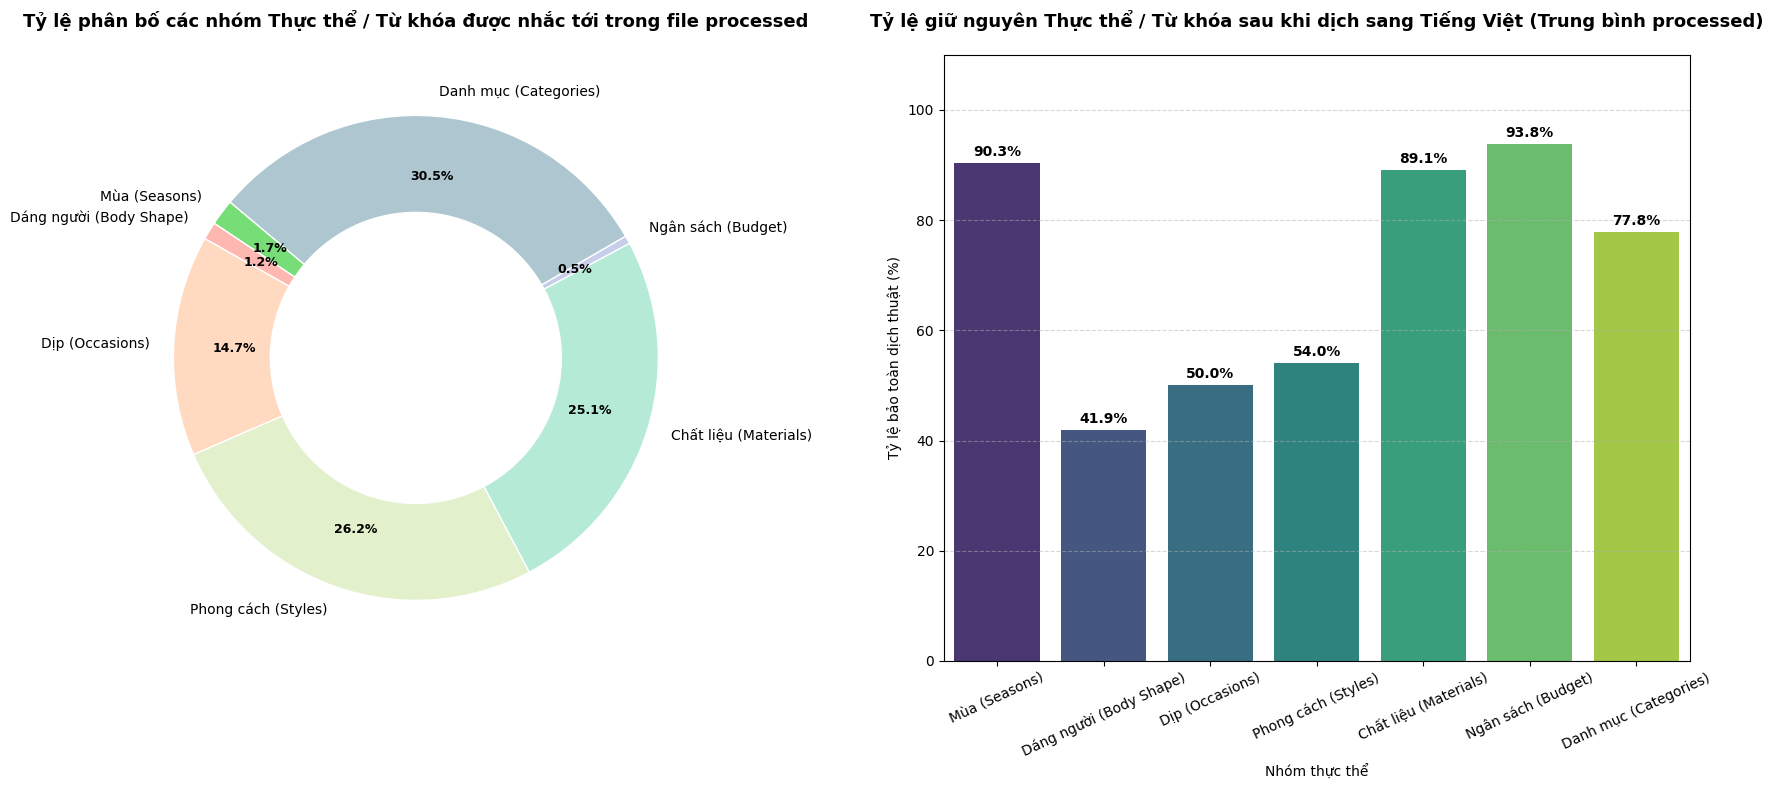

In [5]:
# Đếm trực tiếp tần suất xuất hiện thực thể trong tập processed
counts = {cat: 0 for cat in entities.keys()}
for idx in range(len(df_clean)):
    text = (str(df_clean.iloc[idx]['original_input']) + ' ' + str(df_clean.iloc[idx]['original_output'])).lower()
    for cat, pattern in cat_patterns.items():
        counts[cat] += len(pattern.findall(text))

total = sum(counts.values())
sizes_donut = [counts[cat] for cat in entities.keys()]
labels_donut = [cat for cat in entities.keys()]
colors_donut = ['#77dd77', '#ffb7b2', '#ffdac1', '#e2f0cb', '#b5ead7', '#c7ceea', '#aec6cf']

# Lấy dữ liệu tỷ lệ giữ nguyên thực thể sau dịch của tập processed (Trung bình cộng của Input và Output)
clean_preservation_rates = []
for cat in entities.keys():
    rate_in = df_stats_clean_in.loc[df_stats_clean_in['Category'] == cat, 'Preservation Rate (%)'].values[0]
    rate_out = df_stats_clean_out.loc[df_stats_clean_out['Category'] == cat, 'Preservation Rate (%)'].values[0]
    avg_rate = (rate_in + rate_out) / 2
    clean_preservation_rates.append({"Category": cat, "Rate": avg_rate})

bar_data_clean = pd.DataFrame(clean_preservation_rates)

# Đồ thị kết hợp Donut (phân bổ nhóm) + Bar Chart (tỷ lệ giữ nguyên trung bình)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Subplot bên trái: Biểu đồ Donut
wedges, texts, autotexts = axes[0].pie(
    sizes_donut, 
    labels=labels_donut, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_donut, 
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white')
)
plt.setp(autotexts, size=9, weight="bold")
axes[0].set_title("Tỷ lệ phân bố các nhóm Thực thể / Từ khóa được nhắc tới trong file processed", fontsize=13, fontweight='bold', pad=20)

# Subplot bên phải: Biểu đồ cột đơn thể hiện tỷ lệ bảo toàn trung bình
sns.barplot(data=bar_data_clean, x="Category", y="Rate", ax=axes[1], palette="viridis")
axes[1].set_title("Tỷ lệ giữ nguyên Thực thể / Từ khóa sau khi dịch sang Tiếng Việt (Trung bình processed)", fontsize=13, fontweight='bold', pad=20)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel("Tỷ lệ bảo toàn dịch thuật (%)")
axes[1].set_xlabel("Nhóm thực thể")
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Điền tỷ lệ phần trăm lên đầu các cột
for p in axes[1].patches:
    height = p.get_height()
    if pd.notnull(height):
        axes[1].annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                    textcoords='offset points', weight='bold')

plt.tight_layout()
plt.savefig('entity_distribution_and_preservation_processed.png', dpi=300, bbox_inches='tight')
plt.show()
